In [ ]:
! sudo apt-get update


Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [119 kB]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,626 B]
Hit:4 https://ppa.launchpadcontent.net/c2d4u.team/c2d4u4.0+/ubuntu jammy InRelease
Get:5 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [109 kB]
Hit:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Get:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:8 http://security.ubuntu.com/ubuntu jammy-security InRelease [110 kB]
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [1,283 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,260 kB]
Get:13 http://archive.ubuntu.com/ubuntu jamm

In [ ]:
# innstall java
!apt-get install openjdk-8-jdk-headless -qq > /dev/null

# install spark (change the version number if needed)
!wget -q https://archive.apache.org/dist/spark/spark-3.0.0/spark-3.0.0-bin-hadoop3.2.tgz

# unzip the spark file to the current folder
!tar xf spark-3.0.0-bin-hadoop3.2.tgz

# set your spark folder to your system path environment.
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.0.0-bin-hadoop3.2"


# install findspark using pip
!pip install -q findspark

#For python users, you should also install pyspark using the following command.

!pip install pyspark

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.8/310.8 MB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyspark: filename=pyspark-3.4.1-py2.py3-none-any.whl size=311285387 sha256=0f57aab2c959f56c531f24c04034565824df0736cc14a50e10c893808e35dd55
  Stored in directory: /root/.cache/pip/wheels/0d/77/a3/ff2f74cc9ab41f8f594dabf0579c2a7c6de920d584206e0834
Successfully built pyspark


In [ ]:
import findspark
findspark.init()

In [ ]:
from google.colab import files
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.sql.functions import isnan, when, count, col, lit,to_date ,hour ,minute ,countDistinct
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml import Pipeline
from pyspark.ml.tuning import CrossValidator
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import ParamGridBuilder
from pyspark.ml.linalg import Vectors
from pyspark.ml.feature import StandardScaler
import pandas as pd
import numpy as np
import seaborn as sb
%matplotlib inline
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution

In [ ]:
sc =SparkSession.builder.master("local").getOrCreate()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df1 = sc.read.csv('/content/drive/MyDrive/ml-df.csv' , inferSchema = True ,header = True)

In [ ]:
df1.show(5)

+---+----+------------------+-------------------+--------+--------------------+---------+--------+-----------+
|_c0|hour|       sum(energy)|apparentTemperature|week_end|                tstp|Adversity|Affluent|Comfortable|
+---+----+------------------+-------------------+--------+--------------------+---------+--------+-----------+
|  0|  20|1475.3700014718343|              15.37|       0|2013-09-12 20:00:...|     1689|    2015|       1431|
|  1|  13|  978.688000012422|              17.32|       0|2013-09-13 13:00:...|     1683|    2011|       1425|
|  2|  10|1096.1420002068626|              11.97|       1|2013-09-14 10:00:...|     1682|    2000|       1420|
|  3|   3| 511.0680005881004|               5.38|       0|2013-10-10 03:00:...|     1676|    1989|       1421|
|  4|   2|   576.27999962389|               5.62|       0|2013-10-11 02:00:...|     1669|    1985|       1414|
+---+----+------------------+-------------------+--------+--------------------+---------+--------+-----------+
o

In [ ]:
df1 = df1.drop('_c0')

In [ ]:
df1 = df1.dropDuplicates()

In [ ]:
df1.count()

19861

In [ ]:
df1.sample(0.01).show(100)

+----+------------------+-------------------+--------+--------------------+---------+--------+-----------+
|hour|       sum(energy)|apparentTemperature|week_end|                tstp|Adversity|Affluent|Comfortable|
+----+------------------+-------------------+--------+--------------------+---------+--------+-----------+
|  10| 732.2850001504412|               24.6|       0|2012-06-28 10:00:...|     1347|    1744|       1028|
|   3|500.31100042315666|              17.49|       0|2012-08-20 03:00:...|     1508|    1983|       1169|
|  11|1032.2670001132647|              13.62|       0|2013-04-17 11:00:...|     1736|    2080|       1456|
|  22| 1666.084999974817|               1.43|       0|2014-01-27 22:00:...|     1646|    1942|       1387|
|  21|1649.8350021156948|               4.66|       0|2012-12-25 21:00:...|     1779|    2139|       1483|
|   8|1109.8630008411128|              -1.38|       1|2013-03-10 08:00:...|     1749|    2092|       1453|
|  19| 17.96000004094094|            

In [ ]:
from pyspark.ml.feature import OneHotEncoder
stages = []
column_list = ['hour' ,'week_end']
for column in column_list :
  encoder = OneHotEncoder(inputCol=column, outputCol=column+"_encoded")
  stages.append(encoder)
pipeline = Pipeline(stages = stages )
df_encoded = pipeline.fit(df1).transform(df1)

In [ ]:
from pyspark.ml.linalg import Vectors
from pyspark.ml.feature import VectorAssembler
vector_assembler = VectorAssembler(inputCols = ['hour_encoded','apparentTemperature',
                                                'week_end_encoded','Adversity','Affluent','Comfortable']
                                   ,outputCol = 'features_vector')
df = vector_assembler.transform(df_encoded)
df.show(3)

+----+-----------------+-------------------+--------+--------------------+---------+--------+-----------+---------------+----------------+--------------------+
|hour|      sum(energy)|apparentTemperature|week_end|                tstp|Adversity|Affluent|Comfortable|   hour_encoded|week_end_encoded|     features_vector|
+----+-----------------+-------------------+--------+--------------------+---------+--------+-----------+---------------+----------------+--------------------+
|  13| 978.688000012422|              17.32|       0|2013-09-13 13:00:...|     1683|    2011|       1425|(23,[13],[1.0])|   (1,[0],[1.0])|(28,[13,23,24,25,...|
|  20|85.83400005474687|               1.28|       0|2011-12-13 20:00:...|       60|      84|         75|(23,[20],[1.0])|   (1,[0],[1.0])|(28,[20,23,24,25,...|
|  11|1040.117000728147|              16.46|       1|2012-08-05 11:00:...|     1509|    1993|       1173|(23,[11],[1.0])|       (1,[],[])|(28,[11,23,25,26,...|
+----+-----------------+----------------

In [ ]:
from pyspark.ml import Pipeline
# expansion parameters
from pyspark.ml.feature import PolynomialExpansion
poly = PolynomialExpansion(degree =2 ,inputCol='features_vector', outputCol='poly_features')
df = poly.transform(df)

In [ ]:
df_train ,df_test = df.randomSplit([0.8,0.2])

In [ ]:
df_train.count() ,df_test.count()

(15788, 4073)

In [ ]:
ss = StandardScaler(withMean=True, withStd=True, inputCol='poly_features' , outputCol='poly_features_scaled')
ss_model =ss.fit(df_train)
df_train = ss_model.transform(df_train)
df_test = ss_model.transform(df_test)

In [ ]:
#from pyspark.ml.feature import PolynomialExpansion
#from pyspark.ml import Pipeline
#poly = PolynomialExpansion(degree =2 ,inputCol='features_vector', outputCol='poly_features')
#ss = StandardScaler(withMean=True, withStd=True, inputCol='poly_features' , outputCol='poly_features_scaled')

In [ ]:
from pyspark.ml.regression import LinearRegression
# elasticnetparam = 0 --> ridge regression (L2 penalty )
lr = LinearRegression(featuresCol='poly_features_scaled', labelCol='sum(energy)',elasticNetParam=0 ,regParam = 0) # regparam = 0 means no regularization
pipeline = Pipeline(stages = [ lr])
from pyspark.ml.tuning import ParamGridBuilder
paramGrid =  ParamGridBuilder().build()
from pyspark.ml.evaluation import RegressionEvaluator
evaluator = RegressionEvaluator(predictionCol='prediction', labelCol='sum(energy)', metricName='r2')
crossval = CrossValidator(estimator=pipeline,
                          estimatorParamMaps=paramGrid,
                          evaluator=evaluator,
                          numFolds=2
                          ,collectSubModels=True
                          )

In [ ]:
from time import time
t0 = time()
cvmodel_plain = crossval.fit(df_train)
fitting_time_lr = time() - t0

In [ ]:
t0 = time()
pred_plain = cvmodel_plain.transform(df_test)
predicting_time_lr = time() - t0

In [ ]:
from pyspark.sql import functions as F

In [ ]:
pred_plain = pred_plain.withColumn(
    "prediction",
    F.when(pred_plain["prediction"] < 0, 0.2).otherwise(F.col("prediction")))

In [ ]:
eval =RegressionEvaluator(labelCol="sum(energy)")
r2_plain = eval.evaluate(pred_plain,{eval.metricName:"r2"})
mae_plain = eval.evaluate(pred_plain,{eval.metricName:"mae"})
rmse_plain = eval.evaluate(pred_plain,{eval.metricName:"rmse"})
mse_plain = eval.evaluate(pred_plain,{eval.metricName:"mse"})
print('r2 of plain= ', r2_plain)
print('mae of plain= ', mae_plain)
print('rmse of plain = ', rmse_plain)
print('mse of plain= ',mse_plain)

r2 of plain=  0.961588373334931
mae of plain=  71.42633037699592
rmse of plain =  102.03674786572044
mse of plain=  10411.497915012606


In [ ]:
print(cvmodel_plain.getEstimatorParamMaps()[np.argmax(cvmodel_plain.avgMetrics)])

{}


In [ ]:
df_features = pd.DataFrame(df.schema["features_vector"].metadata["ml_attr"]["attrs"]["binary"]+df.schema["features_vector"].metadata["ml_attr"]["attrs"]["numeric"]).sort_values("idx")
features_list = df_features['name'].tolist()
print(len(features_list))
features_list.insert(0,str(1))



28


In [ ]:
poly_features_list = []
for i in range(1,29):
  for j in range(i+1):
    poly_features_list.append(features_list[i] + '*' +features_list[j])
print(len(poly_features_list))

434


In [ ]:
plain_coeffs = cvmodel_plain.bestModel.stages[0].coefficients.values.tolist()
e = {'features':poly_features_list , 'coefficients' :plain_coeffs }
df_features_coeffs_plain = pd.DataFrame(data = e)
#df_features_coeffs_lasso_sorted = df_features_coeffs_lasso.sort_values(by= 'coefficients',ascending=False)
df_features_coeffs_plain['coefficients_abs'] = df_features_coeffs_plain['coefficients'].apply(abs)
df_features_coeffs_plain_sorted = df_features_coeffs_plain.sort_values(by = 'coefficients_abs',ascending=False)
df_features_coeffs_plain_sorted

,features,coefficients,coefficients_abs
376,Adversity*Adversity,417.655546,417.655546
404,Affluent*Affluent,-296.030393,296.030393
377,Affluent*1,292.587530,292.587530
431,Comfortable*Adversity,208.220548,208.220548
378,Affluent*hour_encoded_0,-207.193519,207.193519
...,...,...,...
246,hour_encoded_20*hour_encoded_15,0.000000,0.000000
247,hour_encoded_20*hour_encoded_16,0.000000,0.000000
248,hour_encoded_20*hour_encoded_17,0.000000,0.000000
249,hour_encoded_20*hour_encoded_18,0.000000,0.000000


In [ ]:
## lasoo
from pyspark.ml.regression import LinearRegression
# elasticnetparam = 0 --> ridge regression (L2 penalty )
lr =LinearRegression( featuresCol='poly_features_scaled', labelCol='sum(energy)',elasticNetParam=1)
pipeline = Pipeline(stages = [lr])
pipeline.write().overwrite().save("pipeline")
pipelineModel = Pipeline.load("pipeline")
# elasticNetParam = Param(parent='undefined', name='elasticNetParam',
#doc='the ElasticNet mixing parameter, in range [0, 1]. For alpha = 0,
#the penalty is an L2 penalty (ridge). For alpha = 1, it is an L1 penalty. (lasso)')
from pyspark.ml.tuning import ParamGridBuilder
paramGrid =  ParamGridBuilder().addGrid(lr.regParam, [1,0.1,.01,.001,0.0001,0.00001]).build()
#paramGrid =  ParamGridBuilder().build()
from pyspark.ml.evaluation import RegressionEvaluator
evaluator = RegressionEvaluator(predictionCol='prediction', labelCol='sum(energy)', metricName='r2')
crossval = CrossValidator(estimator=pipelineModel,
                          estimatorParamMaps=paramGrid,
                          evaluator=evaluator,
                          numFolds=4 ,collectSubModels=True)


In [ ]:
#t0 = time()
cvmodel_lasso = crossval.fit(df_train)
#fitting_time_lasso = time() - t0

In [ ]:
print(cvmodel_lasso.getEstimatorParamMaps()[np.argmax(cvmodel_lasso.avgMetrics)])

{Param(parent='LinearRegression_da87fa769b9c', name='regParam', doc='regularization parameter (>= 0).'): 0.0001}


In [ ]:
cvmodel_lasso.avgMetrics

[0.9604391445809901,
 0.9626476058671345,
 0.9625873400075062,
 0.9626718535372727,
 0.9626815855166381,
 0.9625805244329317]

In [ ]:
#t0 = time()
pred_lasso = cvmodel_lasso.transform(df_test)
#predicting_time_lasso = time() - t0

In [ ]:
pred_lasso.withColumn(
    "prediction",
    F.when(pred_lasso["prediction"] < 0, 0.2).otherwise(F.col("prediction")))

DataFrame[hour: int, sum(energy): double, apparentTemperature: double, week_end: int, tstp: string, Adversity: int, Affluent: int, Comfortable: int, hour_encoded: vector, week_end_encoded: vector, features_vector: vector, poly_features: vector, poly_features_scaled: vector, prediction: double]

In [ ]:
eval =RegressionEvaluator(labelCol="sum(energy)")
r2_lasso = eval.evaluate(pred_lasso,{eval.metricName:"r2"})
rmse_lasso= eval.evaluate(pred_lasso,{eval.metricName:"rmse"})
mse_lasso= eval.evaluate(pred_lasso,{eval.metricName:"mse"})
mae_lasso= eval.evaluate(pred_lasso,{eval.metricName:"mae"})
print('r2 of lasso=' ,r2_lasso)
print('rmse of lasso= ',rmse_lasso)
print('mse of lasso=' , mse_lasso)
print('mae of lasso= ', mae_lasso)

r2 of lasso= 0.9597914871865099
rmse of lasso=  104.3960973674483
mse of lasso= 10898.545145553746
mae of lasso=  72.95332339608052


In [ ]:
lasso_coeffs = cvmodel_lasso.bestModel.stages[0].coefficients.values.tolist()
e = {'features':poly_features_list , 'coefficients' :lasso_coeffs }
df_features_coeffs_lasso = pd.DataFrame(data = e)
#df_features_coeffs_lasso_sorted = df_features_coeffs_lasso.sort_values(by= 'coefficients',ascending=False)
df_features_coeffs_lasso['coefficients_abs'] = df_features_coeffs_lasso['coefficients'].apply(abs)
df_features_coeffs_lasso_sorted = df_features_coeffs_lasso.sort_values(by = 'coefficients_abs',ascending=False)
df_features_coeffs_lasso_sorted

,features,coefficients,coefficients_abs
377,Affluent*1,151.424322,151.424322
350,Adversity*1,112.942838,112.942838
405,Comfortable*1,93.525666,93.525666
429,Comfortable*apparentTemperature,-68.479286,68.479286
374,Adversity*apparentTemperature,-57.555292,57.555292
...,...,...,...
255,hour_encoded_21*hour_encoded_2,0.000000,0.000000
256,hour_encoded_21*hour_encoded_3,0.000000,0.000000
257,hour_encoded_21*hour_encoded_4,0.000000,0.000000
258,hour_encoded_21*hour_encoded_5,0.000000,0.000000


In [ ]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

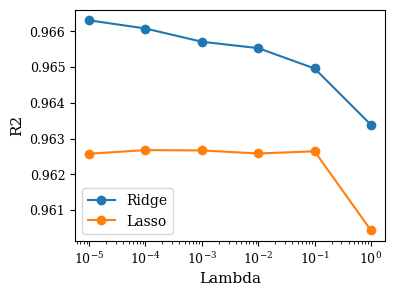

In [ ]:
alphas = [1,0.1,.01,.001,0.0001,0.00001]
 #cvmodel_ridge.avgMetrics
 #cvmodel_lasso.avgMetrics
plt.figure(figsize = [4,3])
plt.plot(alphas , cvmodel_ridge.avgMetrics , 'o-' ,label = 'Ridge')
plt.xscale('log')
plt.plot(alphas , cvmodel_lasso.avgMetrics , 'o-',label = 'Lasso')
plt.legend()
from google.colab import files
plt.xlabel('Lambda', fontsize = 11) ;
plt.ylabel('R2' , fontsize =11) ;
plt.xticks(fontsize = 9);
plt.yticks(fontsize = 9);
plt.savefig("Ridge and lasso lambdas aganist R2.png",dpi = 300,bbox_inches= 'tight')
files.download("Ridge and lasso lambdas aganist R2.png")

In [ ]:
models = {}
for l in cvmodel_lasso.subModels:
  for m in l:
    #print(m.stages[0].coefficients)
    #print(m.stages[0].getRegParam())
    models[m.stages[0].getRegParam()]= m.stages[0].coefficients.values.tolist() ## dcit for one fold
sub_model = pd.DataFrame(models , index = poly_features_list)
top = sub_model.abs().sort_values(by = [0.001],ascending = False)
#top.loc['count(LCLid)*count(LCLid)']
top = top.head()
top

,1.00000,0.10000,0.01000,0.00100,0.00010,0.00001
Affluent*1,156.153916,166.562812,179.520985,154.220748,155.610418,143.586766
Adversity*1,123.370775,130.424423,101.127587,127.463379,126.597696,153.899667
Comfortable*apparentTemperature,70.499877,76.472463,77.624334,92.939882,105.592051,112.741259
Comfortable*1,64.698411,66.825354,66.420459,73.198895,77.155436,65.596289
Adversity*apparentTemperature,56.465481,65.423916,66.847607,59.023712,46.702762,45.008102


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

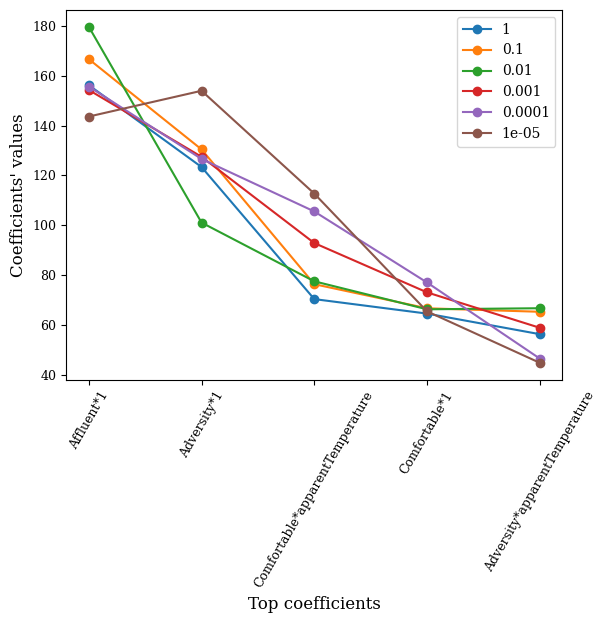

In [ ]:
plt.plot(top[1] ,   '-o',label =1 )
plt.plot(top[0.1] ,   '-o',label =0.1 )
plt.plot(top[0.01] ,   '-o',label =0.01 )
plt.plot(top[0.001] ,   '-o',label =0.001 )
plt.plot(top[0.0001] ,   '-o',label =1e-4 )
plt.plot(top[0.00001] ,   '-o',label =1e-5 )
#plt.xticks(ticks=[0,1,2,3,4],labels = ['Count(LCLid)','Count(LCLid)*App. temperature','Count(LCLid)*Count(LCLid)','Count(LCLid)*Hour #19','Count(LCLid)*Hour #20'],rotation = 60,fontsize =9)
h = plt.xticks(rotation = 60,fontsize =9)

plt.yticks(fontsize = 9)
plt.xlabel('Top coefficients' ,fontsize =12 )
plt.ylabel("Coefficients' values",fontsize =12)
plt.legend()
from google.colab import files

plt.savefig("Effect of lambda on lasso model top 5 coefficients (all blocks).png",dpi = 300,bbox_inches= 'tight')
files.download("Effect of lambda on lasso model top 5 coefficients (all blocks).png")

In [ ]:
## ridge
from pyspark.ml.regression import LinearRegression
# elasticnetparam = 0 --> ridge regression (L2 penalty )
lr =LinearRegression( featuresCol='poly_features_scaled', labelCol='sum(energy)',elasticNetParam=0.0)
pipeline = Pipeline(stages = [lr])
from pyspark.ml.evaluation import RegressionEvaluator
evaluator = RegressionEvaluator(predictionCol='prediction', labelCol='sum(energy)', metricName='r2')
from pyspark.ml.tuning import ParamGridBuilder
paramGrid =  ParamGridBuilder().addGrid(lr.regParam,  [1,0.1,.01,.001,0.0001,0.00001]).build()
crossval = CrossValidator(estimator=pipeline,
                          estimatorParamMaps=paramGrid,
                          evaluator=evaluator,
                          numFolds=2 ,collectSubModels=True)

In [ ]:
## fit model
#t0 = time()
cvmodel_ridge = crossval.fit(df_train)
#fitting_time_ridge = time() - t0

In [ ]:
print(cvmodel_ridge.getEstimatorParamMaps()[np.argmax(cvmodel_ridge.avgMetrics)])

{Param(parent='LinearRegression_0801ab5c8978', name='regParam', doc='regularization parameter (>= 0).'): 1e-05}


In [ ]:
cvmodel_ridge.avgMetrics

[0.9633906537575283,
 0.9649636722494652,
 0.9655327134628833,
 0.965711051268328,
 0.9660809973172252,
 0.9663098196233938]

In [ ]:
#t0 = time()
pred_ridge = cvmodel_ridge.transform(df_test)
#predicting_time_ridge = time() - t0

In [ ]:
pred_ridge.withColumn(
    "prediction",
    F.when(pred_ridge["prediction"] < 0, 0.2).otherwise(F.col("prediction")))

DataFrame[hour: int, sum(energy): double, apparentTemperature: double, week_end: int, tstp: string, Adversity: int, Affluent: int, Comfortable: int, hour_encoded: vector, week_end_encoded: vector, features_vector: vector, poly_features: vector, poly_features_scaled: vector, prediction: double]

In [ ]:
eval =RegressionEvaluator(labelCol="sum(energy)")
r2_ridge = eval.evaluate(pred_ridge,{eval.metricName:"r2"})
rmse_ridge= eval.evaluate(pred_ridge,{eval.metricName:"rmse"})
mse_ridge= eval.evaluate(pred_ridge,{eval.metricName:"mse"})
mae_ridge= eval.evaluate(pred_ridge,{eval.metricName:"mae"})
print('r2 of ridge =' ,r2_ridge)
print('rmse of ridge = ',rmse_ridge)
print('mse of ridge =' , mse_ridge)
print('mae of ridge = ', mae_ridge)

r2 of ridge = 0.9637606386095182
rmse of ridge =  99.10955510584789
mse of ridge = 9822.7039132791
mae of ridge =  69.87297410259323


In [ ]:
ridge_coeffs = cvmodel_ridge.bestModel.stages[0].coefficients.values.tolist()
e = {'features':poly_features_list , 'coefficients' :ridge_coeffs }
df_features_coeffs_ridge = pd.DataFrame(data = e)
#df_features_coeffs_lasso_sorted = df_features_coeffs_lasso.sort_values(by= 'coefficients',ascending=False)
df_features_coeffs_ridge['coefficients_abs'] = df_features_coeffs_ridge['coefficients'].apply(abs)
df_features_coeffs_ridge_sorted = df_features_coeffs_ridge.sort_values(by = 'coefficients_abs',ascending=False)
df_features_coeffs_ridge_sorted

,features,coefficients,coefficients_abs
431,Comfortable*Adversity,28622.790727,28622.790727
433,Comfortable*Comfortable,-13868.324396,13868.324396
376,Adversity*Adversity,-12899.407786,12899.407786
432,Comfortable*Affluent,-2051.809223,2051.809223
350,Adversity*1,829.533878,829.533878
...,...,...,...
267,hour_encoded_21*hour_encoded_14,0.000000,0.000000
268,hour_encoded_21*hour_encoded_15,0.000000,0.000000
269,hour_encoded_21*hour_encoded_16,0.000000,0.000000
270,hour_encoded_21*hour_encoded_17,0.000000,0.000000


In [ ]:
## elastic net
from pyspark.ml.regression import LinearRegression
# elasticnetparam = 0 --> ridge regression (L2 penalty )
lr =LinearRegression( featuresCol='poly_features_scaled', labelCol='sum(energy)')
pipeline = Pipeline(stages = [lr])
pipeline.write().overwrite().save("pipeline")
pipelineModel = Pipeline.load("pipeline")
from pyspark.ml.evaluation import RegressionEvaluator
evaluator = RegressionEvaluator(predictionCol='prediction', labelCol='sum(energy)', metricName='r2')
# elasticNetParam = Param(parent='undefined', name='elasticNetParam',
#doc='the ElasticNet mixing parameter, in range [0, 1]. For alpha = 0,
#the penalty is an L2 penalty (ridge). For alpha = 1, it is an L1 penalty. (lasso)')
from pyspark.ml.tuning import ParamGridBuilder
paramGrid =  ParamGridBuilder().addGrid(poly.degree,[2]).addGrid(lr.regParam, [1,0.1,0.01,0.001,0.0001,0.00001]).addGrid(lr.elasticNetParam ,[0,0.1,0.2,0.5,0.7,0.8,1]).build()
crossval = CrossValidator(estimator=pipelineModel,
                          estimatorParamMaps=paramGrid,
                          evaluator=evaluator,
                          numFolds=2 ,collectSubModels=True)

In [ ]:
## fit model
t0 = time()
cvmodel_elastic = crossval.fit(df_train)
fitting_time_elastic = time() - t0

In [ ]:
print(cvmodel_elastic.getEstimatorParamMaps()[np.argmax(cvmodel_elastic.avgMetrics)])

{Param(parent='PolynomialExpansion_a78a0ad07ba7', name='degree', doc='the polynomial degree to expand (>= 1)'): 2, Param(parent='LinearRegression_ac7492c6b472', name='regParam', doc='regularization parameter (>= 0).'): 1e-05, Param(parent='LinearRegression_ac7492c6b472', name='elasticNetParam', doc='the ElasticNet mixing parameter, in range [0, 1]. For alpha = 0, the penalty is an L2 penalty. For alpha = 1, it is an L1 penalty.'): 0.0}


In [ ]:
t0 = time()
pred_elastic = cvmodel_elastic.transform(df_test)
predicting_time_elastic = time() - t0

In [ ]:
pred_elastic.withColumn(
    "prediction",
    F.when(pred_elastic["prediction"] < 0, 0.2).otherwise(F.col("prediction")))

DataFrame[hour: int, sum(energy): double, apparentTemperature: double, week_end: int, tstp: string, Adversity: int, Affluent: int, Comfortable: int, hour_encoded: vector, week_end_encoded: vector, features_vector: vector, poly_features: vector, poly_features_scaled: vector, prediction: double]

In [ ]:
eval =RegressionEvaluator(labelCol="sum(energy)")
r2_elastic = eval.evaluate(pred_elastic,{eval.metricName:"r2"})
rmse_elastic= eval.evaluate(pred_elastic,{eval.metricName:"rmse"})
mse_elastic= eval.evaluate(pred_elastic,{eval.metricName:"mse"})
mae_elastic= eval.evaluate(pred_elastic,{eval.metricName:"mae"})
print('r2 of elastic net  =' ,r2_elastic)
print('rmse elastic net = ',rmse_elastic)
print('mse elastic net=' , mse_elastic)
print('mae elastic net= ', mae_elastic)

r2 of elastic net  = 0.9637006935619539
rmse elastic net =  99.61994797524457
mse elastic net= 9924.134034590435
mae elastic net=  70.37335465583149


In [ ]:
pred_p= pred_plain.select('tstp','prediction','sum(energy)')
pred_l= pred_lasso.select('tstp','prediction','sum(energy)')
pred_r= pred_ridge.select('tstp','prediction','sum(energy)')
pred_e= pred_elastic.select('tstp','prediction','sum(energy)')

In [ ]:
pred_plain_train = cvmodel_plain.transform(df_train)
pred_lasso_train = cvmodel_lasso.transform(df_train)
pred_ridge_train = cvmodel_ridge.transform(df_train)
pred_elastic_train = cvmodel_elastic.transform(df_train)


In [ ]:
pred_plain_train = pred_plain_train.select('tstp','prediction','sum(energy)')
pred_lasso_train= pred_lasso_train.select('tstp','prediction','sum(energy)')
pred_ridge_train= pred_ridge_train.select('tstp','prediction','sum(energy)')
pred_elastic_train= pred_elastic_train.select('tstp','prediction','sum(energy)')

In [ ]:
pred_plain = pred_plain_train.union(pred_p)
pred_lasso= pred_lasso_train.union(pred_l)
pred_ridge = pred_ridge_train.union(pred_r)
pred_elastic= pred_elastic_train.union(pred_e)

In [ ]:
pred_plain = pred_plain.toPandas()
pred_lasso = pred_lasso.toPandas()
pred_ridge= pred_ridge.toPandas()
pred_elastic = pred_elastic.toPandas()

In [ ]:
pred_plain['tstp'] =pred_plain['tstp'].astype('datetime64')
pred_lasso['tstp'] =pred_lasso['tstp'].astype('datetime64')
pred_ridge['tstp'] =pred_ridge['tstp'].astype('datetime64')
pred_elastic['tstp'] =pred_elastic['tstp'].astype('datetime64')

In [ ]:
pred_plain.sort_values(by = ['tstp'],inplace =True )
pred_lasso.sort_values(by = ['tstp'],inplace =True )
pred_ridge.sort_values(by = ['tstp'],inplace =True )
pred_elastic.sort_values(by = ['tstp'],inplace =True )

In [ ]:
pred_plain_2013 = pred_plain[(pred_plain['tstp'] > '2013-02-01 00:00:00') & (pred_plain['tstp'] <= '2013-02-07 00:00:00')]
pred_lasso_2013 = pred_lasso[(pred_plain['tstp'] > '2013-02-01 00:00:00') & (pred_lasso['tstp'] <= '2013-02-07 00:00:00')]
pred_ridge_2013 = pred_ridge[(pred_plain['tstp'] > '2013-02-01 00:00:00') & (pred_ridge['tstp'] <= '2013-02-07 00:00:00')]
pred_elastic_2013 = pred_elastic[(pred_plain['tstp'] > '2013-02-01 00:00:00') & (pred_elastic['tstp'] <= '2013-02-07 00:00:00')]

## Regression tree model

In [ ]:
df1.show(5)

+----+------------------+-------------------+--------+--------------------+---------+--------+-----------+
|hour|       sum(energy)|apparentTemperature|week_end|                tstp|Adversity|Affluent|Comfortable|
+----+------------------+-------------------+--------+--------------------+---------+--------+-----------+
|  13|  978.688000012422|              17.32|       0|2013-09-13 13:00:...|     1683|    2011|       1425|
|  20| 85.83400005474687|               1.28|       0|2011-12-13 20:00:...|       60|      84|         75|
|  11| 1040.117000728147|              16.46|       1|2012-08-05 11:00:...|     1509|    1993|       1173|
|  17|466.86600048386026|              11.94|       0|2012-04-25 17:00:...|      552|     896|        428|
|  22|1290.8940013707615|              11.46|       0|2012-10-15 22:00:...|     1704|    2098|       1382|
+----+------------------+-------------------+--------+--------------------+---------+--------+-----------+
only showing top 5 rows



In [ ]:
from pyspark.ml.linalg import Vectors
from pyspark.ml.feature import VectorAssembler
vector_assembler = VectorAssembler(inputCols = ['hour','apparentTemperature' ,'week_end','Adversity','Affluent','Comfortable']
                                   ,outputCol = 'features_vector')
df1 = vector_assembler.transform(df1)
df1.show(3)

+----+-----------------+-------------------+--------+--------------------+---------+--------+-----------+--------------------+
|hour|      sum(energy)|apparentTemperature|week_end|                tstp|Adversity|Affluent|Comfortable|     features_vector|
+----+-----------------+-------------------+--------+--------------------+---------+--------+-----------+--------------------+
|  13| 978.688000012422|              17.32|       0|2013-09-13 13:00:...|     1683|    2011|       1425|[13.0,17.32,0.0,1...|
|  20|85.83400005474687|               1.28|       0|2011-12-13 20:00:...|       60|      84|         75|[20.0,1.28,0.0,60...|
|  11|1040.117000728147|              16.46|       1|2012-08-05 11:00:...|     1509|    1993|       1173|[11.0,16.46,1.0,1...|
+----+-----------------+-------------------+--------+--------------------+---------+--------+-----------+--------------------+
only showing top 3 rows



In [ ]:
df_train ,df_test = df1.randomSplit([0.8,0.2])
from pyspark.ml.evaluation import RegressionEvaluator
evaluator = RegressionEvaluator(predictionCol='prediction', labelCol='sum(energy)', metricName='r2')
from pyspark.ml.regression import DecisionTreeRegressor
DTR = DecisionTreeRegressor(featuresCol= 'features_vector', labelCol= 'sum(energy)')
from pyspark.ml.tuning import ParamGridBuilder
paramGrid =  ParamGridBuilder().addGrid(DTR.maxDepth, [11,12,13,14,15]).build()
crossval = CrossValidator(estimator=DTR,
                          estimatorParamMaps=paramGrid,
                          evaluator=evaluator,
                          numFolds=3
                          ,collectSubModels=True
                          )

In [ ]:
from time import time
t0 =time()
cvmodel_tree = crossval.fit(df_train)
fitting_time_tree = time() - t0

In [ ]:
print(cvmodel_tree.getEstimatorParamMaps()[np.argmax(cvmodel_tree.avgMetrics)])

{Param(parent='DecisionTreeRegressor_51d4e9a0927d', name='maxDepth', doc='Maximum depth of the tree. (>= 0) E.g., depth 0 means 1 leaf node; depth 1 means 1 internal node + 2 leaf nodes.'): 12}


In [ ]:
t0 = time()
pred_tree = cvmodel_tree.transform(df_test)
predicting_time_tree = time() -t0

In [ ]:
DTRM = cvmodel_tree.bestModel
def tree_json(tree):
	data = []
	for line in tree.splitlines() :
		if line.strip():
			line = line.strip()
			data.append(line)
		else : break
		if not line : break
	res = []
	res.append({'name':'Root', 'children':parse(data[1:])})
	with open('/content/drive/MyDrive/decision_rules_load_all_blocks.txt', 'w') as outfile:
		json.dump(res[0], outfile)
	print ('Conversion Success !')
def parse(lines):
		block = []
		while lines :

			if lines[0].startswith('If'):
				bl = ' '.join(lines.pop(0).split()[1:]).replace('(', '').replace(')', '')
				block.append({'name':bl, 'children':parse(lines)})


				if lines[0].startswith('Else'):
					be = ' '.join(lines.pop(0).split()[1:]).replace('(', '').replace(')', '')
					block.append({'name':be, 'children':parse(lines)})
			elif not lines[0].startswith(('If','Else')):
				block2 = lines.pop(0)
				block.append({'name':block2})
			else:
				break
		return block

In [ ]:
DTRM

DecisionTreeRegressionModel: uid=DecisionTreeRegressor_51d4e9a0927d, depth=12, numNodes=4895, numFeatures=6

In [ ]:
tree_to_plot = DTRM.toDebugString

In [ ]:
tree_to_plot

'DecisionTreeRegressionModel: uid=DecisionTreeRegressor_51d4e9a0927d, depth=12, numNodes=4895, numFeatures=6\n  If (feature 3 <= 1259.5)\n   If (feature 5 <= 409.5)\n    If (feature 5 <= 160.5)\n     If (feature 4 <= 114.5)\n      If (feature 1 <= 6.025)\n       If (feature 0 <= 7.5)\n        If (feature 1 <= 3.855)\n         If (feature 1 <= -1.2650000000000001)\n          If (feature 0 <= 1.5)\n           If (feature 1 <= -2.875)\n            If (feature 0 <= 0.5)\n             Predict: 64.21399974264205\n            Else (feature 0 > 0.5)\n             Predict: 65.3130001872778\n           Else (feature 1 > -2.875)\n            If (feature 0 <= 0.5)\n             Predict: 55.70799996482674\n            Else (feature 0 > 0.5)\n             Predict: 41.96700004860759\n          Else (feature 0 > 1.5)\n           If (feature 0 <= 5.5)\n            If (feature 1 <= -2.875)\n             If (feature 0 <= 2.5)\n              Predict: 54.08800011686981\n             Else (feature 0 > 2.5)\

In [ ]:
import json
#from bson import json_util
#from bson.json_util import dumps

In [ ]:
tree_json(DTRM.toDebugString)

Conversion Success !


In [ ]:
df1.schema['features_vector'].metadata["ml_attr"]["attrs"]

{'numeric': [{'idx': 0, 'name': 'hour'},
  {'idx': 1, 'name': 'apparentTemperature'},
  {'idx': 2, 'name': 'week_end'},
  {'idx': 3, 'name': 'Adversity'},
  {'idx': 4, 'name': 'Affluent'},
  {'idx': 5, 'name': 'Comfortable'}]}

In [ ]:
eval =RegressionEvaluator(labelCol="sum(energy)")
r2_tree = eval.evaluate(pred_tree,{eval.metricName:"r2"})
rmse_tree = eval.evaluate(pred_tree,{eval.metricName:"rmse"})
mse_tree = eval.evaluate(pred_tree,{eval.metricName:"mse"})
mae_tree = eval.evaluate(pred_tree,{eval.metricName:"mae"})
print('r2 of decision tree = ',r2_tree)
print('rmse of decision tree = ',rmse_tree)
print('mse of decision tree = ',mse_tree)
print('mae of decision tree = ',mae_tree)

r2 of decision tree =  0.9818054679500506
rmse of decision tree =  71.32108090164981
mse of decision tree =  5086.696580979677
mae of decision tree =  46.565879675770525


In [ ]:
pred_tree_tarin = cvmodel_tree.transform(df_train)

In [ ]:
pred_tree = pred_tree_tarin.union(pred_tree)

In [ ]:
pred_tree = pred_tree.toPandas()

In [ ]:
pred_tree.to_csv('/content/drive/MyDrive/predictions_regression_tree_allblocks_dtou_evaluation.csv')

In [ ]:
pred_tree['tstp'] =pred_tree['tstp'].astype('datetime64')

In [ ]:
pred_tree.sort_values(by = ['tstp'],inplace =True )


In [ ]:
print('fitting time of plain linear regression model = ' ,fitting_time_lr )
print('predicting time of plain linear regression model = ' ,predicting_time_lr )
print('fitting time of lasso regression model = ' ,fitting_time_lasso )
print('predicting time of lasso regression model = ' ,predicting_time_lasso )
print('fitting time of ridge regression model = ' ,fitting_time_ridge )
print('predicting time of ridge regression model = ' ,predicting_time_ridge )
print('fitting time of elastic regression model = ' ,fitting_time_elastic )
print('predicting time of elastic regression model = ' ,predicting_time_elastic )
print('fitting time of RT  model = ' ,fitting_time_tree )
print('predicting time of RT model = ' ,predicting_time_tree )

fitting time of plain linear regression model =  65.23904085159302
predicting time of plain linear regression model =  0.0251007080078125
fitting time of lasso regression model =  242.15638661384583
predicting time of lasso regression model =  0.04701638221740723
fitting time of ridge regression model =  108.68610382080078
predicting time of ridge regression model =  0.021752357482910156
fitting time of elastic regression model =  632.4809143543243
predicting time of elastic regression model =  0.016150236129760742
fitting time of RT  model =  1790.6485764980316
predicting time of RT model =  0.018300533294677734


In [ ]:
pred_plain_2013 = pred_plain[(pred_plain['tstp'] > '2013-03-14 00:00:00') & (pred_plain['tstp'] <= '2013-03-19 00:00:00')]
pred_lasso_2013 = pred_lasso[(pred_plain['tstp'] > '2013-03-14 00:00:00') & (pred_lasso['tstp'] <= '2013-03-19 00:00:00')]
pred_ridge_2013 = pred_ridge[(pred_plain['tstp'] > '2013-03-14 00:00:00') & (pred_ridge['tstp'] <= '2013-03-19 00:00:00')]
pred_elastic_2013 = pred_elastic[(pred_plain['tstp'] > '2013-03-14 00:00:00') & (pred_elastic['tstp'] <= '2013-03-19 00:00:00')]
pred_tree_2013 = pred_tree[(pred_tree['tstp'] > '2013-03-14 00:00:00') & (pred_tree['tstp'] <= '2013-03-19 00:00:00')]

In [ ]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

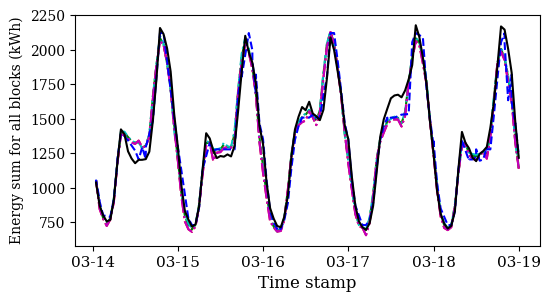

In [ ]:
plt.figure(figsize=[6,3])

plt.xlabel('Time stamp',fontsize = 12,fontweight = 540)
plt.ylabel('Energy sum for all blocks (kWh)',fontsize = 10, fontweight =540)
plt.yticks(fontsize = 10,fontweight = 545)
plt.xticks(ticks= [15778 ,15779,15780,15781,15782,15783],labels = ['03-14','03-15','03-16','03-17','03-18','03-19']
           ,fontsize = 11  ,fontweight = 545)

plt.plot(pred_plain_2013['tstp'] ,pred_plain_2013['prediction'], linestyle='--', linewidth = 1.5,color ='g',label = 'Plain')
plt.plot(pred_lasso_2013['tstp'] ,pred_lasso_2013['prediction'], linestyle='-.', linewidth = 1.5,color ='c',label = 'Lasso')
plt.plot(pred_ridge_2013['tstp'] ,pred_ridge_2013['prediction'], linestyle='-.', linewidth = 1.5,color='r',label ='Ridge')
plt.plot(pred_elastic_2013['tstp'] ,pred_elastic_2013['prediction'],linestyle='-.', linewidth = 1.5,color= 'm',label ='Elastic net')
plt.plot(pred_tree_2013['tstp'] ,pred_tree_2013['prediction'],linestyle='--', linewidth = 1.5,color= 'b',label = 'DTR')
plt.plot(pred_plain_2013['tstp'] ,pred_lasso_2013['sum(energy)'], linestyle='-', linewidth = 1.5 ,color= 'k',label= 'Actual')
#plt.legend(loc=1,ncols = 6 ,fontsize = 9)
from google.colab import files
plt.savefig("Actual and predicted energies for all blocks.png",dpi = 300,bbox_inches= 'tight')
files.download("Actual and predicted energies for all blocks.png")

In [ ]:
d

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(15778.0, 0, '2013-03-14'),
  Text(15779.0, 0, '2013-03-15'),
  Text(15780.0, 0, '2013-03-16'),
  Text(15781.0, 0, '2013-03-17'),
  Text(15782.0, 0, '2013-03-18'),
  Text(15783.0, 0, '2013-03-19')])